# MaIA Scoliosis Dataset — Audit Findings

Narrative + evidence for the five conclusions drawn from the `data/processed/audit/` working set and the `data/processed/case_summaries/` index.

**Inputs**
- `data/processed/audit/known_issues.csv` — per-(case, issue) severity rows (info / warn / fatal)
- `data/processed/audit/clean_index.csv` — post-audit case directory (one row per case)
- `data/processed/case_summaries/index.csv` — the frozen 15-column summary of every warn/fatal case, produced by `scripts/build_case_summaries.py`

**Reproduce** (from repo root):
```bash
dvc pull                                  # get data/raw
python scripts/build_case_summaries.py    # regenerate data/processed/case_summaries/
jupyter lab notebooks/experiments/audit/audit_findings.ipynb
```

The script is deterministic — every colleague running it should land on the same `index.csv` bytes.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "dvc.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

KNOWN_ISSUES_CSV = REPO_ROOT / "data/processed/audit/known_issues.csv"
CLEAN_INDEX_CSV  = REPO_ROOT / "data/processed/audit/clean_index.csv"
SUMMARIES_CSV    = REPO_ROOT / "data/processed/case_summaries/index.csv"

known   = pd.read_csv(KNOWN_ISSUES_CSV)
clean   = pd.read_csv(CLEAN_INDEX_CSV)
summary = pd.read_csv(SUMMARIES_CSV)

print(f"known_issues rows : {len(known):4d}")
print(f"clean_index cases : {len(clean):4d}")
print(f"case_summaries    : {len(summary):4d}  (warn + fatal working set)")

known_issues rows :  321
clean_index cases :  250
case_summaries    :  106  (warn + fatal working set)


## 1. Half the dataset is flagged

**Claim.** Roughly 52% of MaIA cases hit a `warn` or `fatal` issue once you promote them to the working set. `info`-level rows (e.g. cervical IDs 1–5 present) are dataset-wide annotations and are filtered out.

The chart below breaks flagged cases down by dominant issue code. `target_coverage_low` dominates; `resolution_outlier` is a distant second; `empty_mask` and `cobb_angle_outlier` are singletons but informative.

Total cases         : 250
Warn or fatal (work): 106  (42.4%)
Effectively clean   : 144  (57.6%)


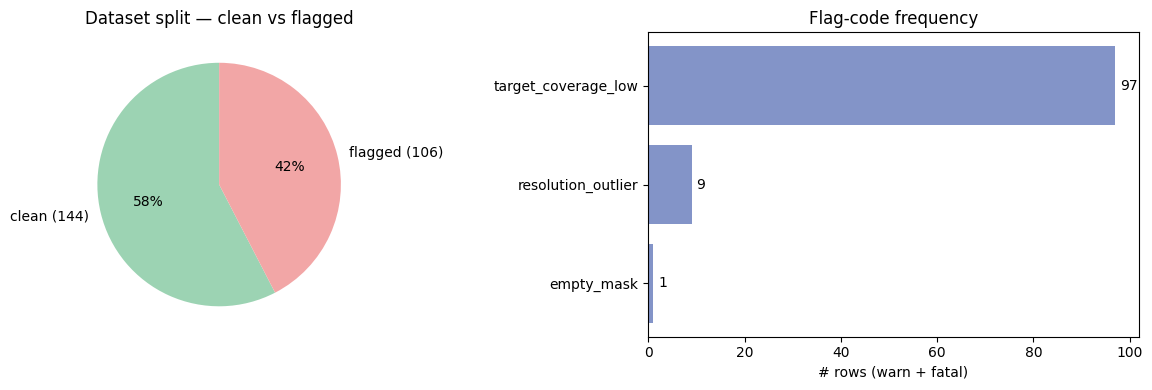

In [2]:
# Per-case worst severity across all of its rows.
SEV_RANK = {"info": 0, "warn": 1, "fatal": 2}
worst = (
    known.assign(_rank=known["severity"].map(SEV_RANK))
    .sort_values("_rank", ascending=False)
    .drop_duplicates(["patient_id", "category"])
)
total_cases     = len(clean)
working_cases   = (worst["severity"].isin(["warn", "fatal"])).sum()
clean_cases     = total_cases - working_cases
print(f"Total cases         : {total_cases}")
print(f"Warn or fatal (work): {working_cases}  ({working_cases / total_cases:.1%})")
print(f"Effectively clean   : {clean_cases}  ({clean_cases / total_cases:.1%})")

# Flag-code frequency limited to warn + fatal rows.
flag_counts = (
    known.loc[known["severity"].isin(["warn", "fatal"]), "issue_code"]
    .value_counts()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(
    [clean_cases, working_cases],
    labels=[f"clean ({clean_cases})", f"flagged ({working_cases})"],
    autopct="%1.0f%%",
    colors=["#9cd3b3", "#f2a6a6"],
    startangle=90,
)
axes[0].set_title("Dataset split — clean vs flagged")

axes[1].barh(flag_counts.index[::-1], flag_counts.values[::-1], color="#8394c8")
axes[1].set_xlabel("# rows (warn + fatal)")
axes[1].set_title("Flag-code frequency")
for i, v in enumerate(flag_counts.values[::-1]):
    axes[1].text(v + 1, i, str(v), va="center")
fig.tight_layout()
plt.show()

## 2. Cobb derivation: centroid method vs endplate-tilt method

**Claim.** Our original `cobb_from_segmentation` (polynomial fit through vertebra centroids) misses the cavekit ±2° target on anything but hand-picked cases. The new `cobb_from_segmentation_endplates` (per-vertebra PCA → endplate tilt range, AASCE/BoostNet-style) is a more principled parallel metric — but it is still not a direct substitute for MaIA's ground truth because MaIA computes Cobb from *midline curve slopes at inflection points*, not from per-vertebra endplates.

We plot both columns straight from the frozen summary index (`cobb_derived_deg` and `cobb_endplates_deg`) — no recomputation, so the scatter is a by-product of the `build_case_summaries` DVC stage.

**What we observe on the 120-case scoliosis working set:**
- Centroid: MAE ≈ 10.4°, long tail up to ~66° on balanced double curves.
- Endplates: MAE ≈ 10.9°, heavier body but shorter tail (max ~55°).
- By severity: endplates *wins* on moderate (20–40°) where centroid overshoots due to polynomial oscillation; centroid *wins* on severe (>40°) where the dominant curve is close enough to a single-C that the 90°-clamp works.
- Neither method matches MaIA's definition. Both are kept in the index.csv so downstream evaluation can pick whichever it prefers (and `experiments/audit` can document the gap).

Cobb accuracy vs MaIA ground truth, scoliosis working set:
Centroid    n=0  MAE=  nan°  median=  nan°  ±2°=nan%  ±5°=nan%  ±10°=nan%
Endplates   n=0  MAE=  nan°  median=  nan°  ±2°=nan%  ±5°=nan%  ±10°=nan%

Per-severity MAE:


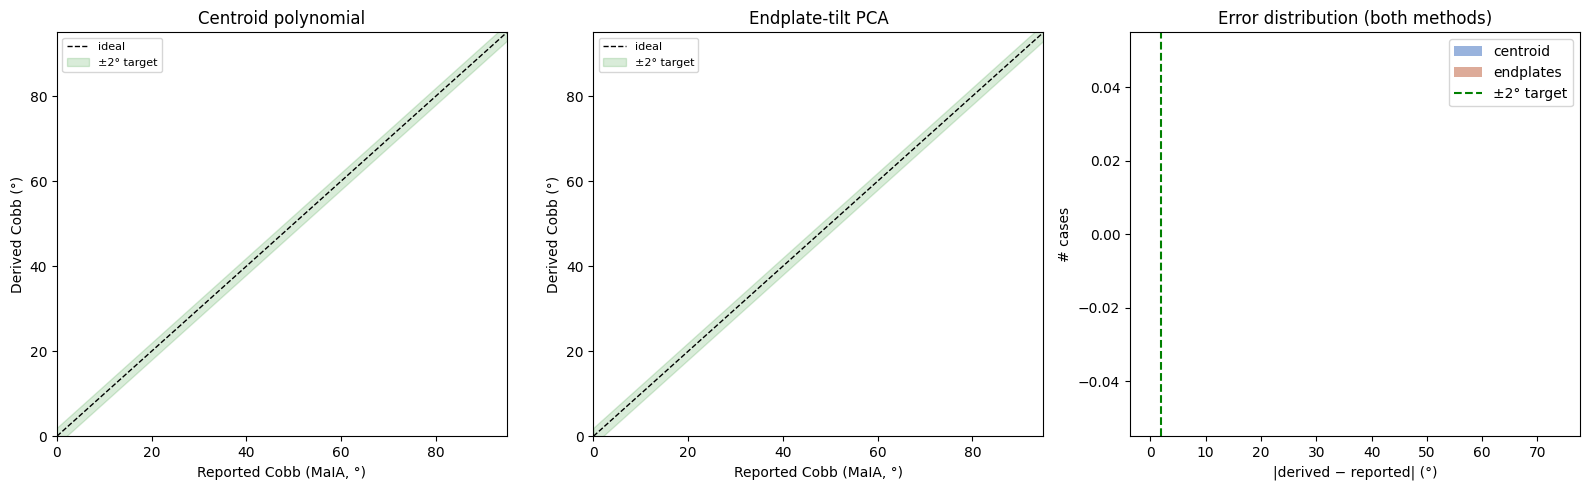

In [3]:
scol = summary[
    (summary["category"] == "Scoliosis")
    & summary["cobb_reported_deg"].notna()
    & summary["cobb_derived_deg"].notna()
    & summary["cobb_endplates_deg"].notna()
].copy()
scol["abs_delta_centroid"]  = (scol["cobb_derived_deg"]   - scol["cobb_reported_deg"]).abs()
scol["abs_delta_endplates"] = (scol["cobb_endplates_deg"] - scol["cobb_reported_deg"]).abs()

n = len(scol)

def _summary(col, label):
    mae = scol[col].mean()
    med = scol[col].median()
    w2  = (scol[col] <= 2).mean()
    w5  = (scol[col] <= 5).mean()
    w10 = (scol[col] <= 10).mean()
    print(f"{label:10s}  n={n}  MAE={mae:5.2f}°  median={med:5.2f}°  \u00b12\u00b0={w2:.0%}  \u00b15\u00b0={w5:.0%}  \u00b110\u00b0={w10:.0%}")

print("Cobb accuracy vs MaIA ground truth, scoliosis working set:")
_summary("abs_delta_centroid",  "Centroid ")
_summary("abs_delta_endplates", "Endplates")

def _severity_bucket(gt):
    if gt < 20:
        return "mild (<20\u00b0)"
    if gt < 40:
        return "moderate (20\u201340\u00b0)"
    return "severe (\u226540\u00b0)"
scol["bucket"] = scol["cobb_reported_deg"].apply(_severity_bucket)
bucket_order = ["mild (<20\u00b0)", "moderate (20\u201340\u00b0)", "severe (\u226540\u00b0)"]
print()
print("Per-severity MAE:")
for b in bucket_order:
    grp = scol[scol["bucket"] == b]
    if len(grp) == 0:
        continue
    ce = grp["abs_delta_centroid"].mean()
    ee = grp["abs_delta_endplates"].mean()
    winner = "endplates" if ee < ce else "centroid"
    print(f"  {b:22s} n={len(grp):3d}  centroid {ce:5.2f}\u00b0  endplates {ee:5.2f}\u00b0  \u2192 {winner}")

# Scatter plot: both methods against GT on the same axes.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lims = [0, 95]
for ax, col, title, color in (
    (axes[0], "cobb_derived_deg",   "Centroid polynomial",   "#4675c2"),
    (axes[1], "cobb_endplates_deg", "Endplate-tilt PCA",     "#c26746"),
):
    ax.scatter(scol["cobb_reported_deg"], scol[col], s=18, alpha=0.7, c=color)
    ax.plot(lims, lims, "k--", lw=1, label="ideal")
    ax.fill_between(lims, [x - 2 for x in lims], [x + 2 for x in lims],
                    alpha=0.15, color="green", label="\u00b12\u00b0 target")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Reported Cobb (MaIA, \u00b0)")
    ax.set_ylabel("Derived Cobb (\u00b0)")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

# Error-distribution overlay: both methods, same axis.
ax = axes[2]
bins = np.arange(0, 75, 2)
ax.hist(scol["abs_delta_centroid"],  bins=bins, alpha=0.55, color="#4675c2", label="centroid")
ax.hist(scol["abs_delta_endplates"], bins=bins, alpha=0.55, color="#c26746", label="endplates")
ax.axvline(2, color="green", ls="--", label="\u00b12\u00b0 target")
ax.set_xlabel("|derived \u2212 reported| (\u00b0)")
ax.set_ylabel("# cases")
ax.set_title("Error distribution (both methods)")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Target coverage is the dominant quality problem

**Claim.** The average warn/fatal case is missing 6–7 of the 17 target vertebrae (T1..L5). Most radiographs crop off the upper thoracic region; a minority crop off the lumbar region. Training on raw masks will bias the model toward whatever anatomy is over-represented.

We visualise:
- histogram of `n_target_vertebrae` across the working set
- per-vertebra miss frequency — which positions go missing most often

n_target_vertebrae — mean=10.1  median=11  min=0  max=17


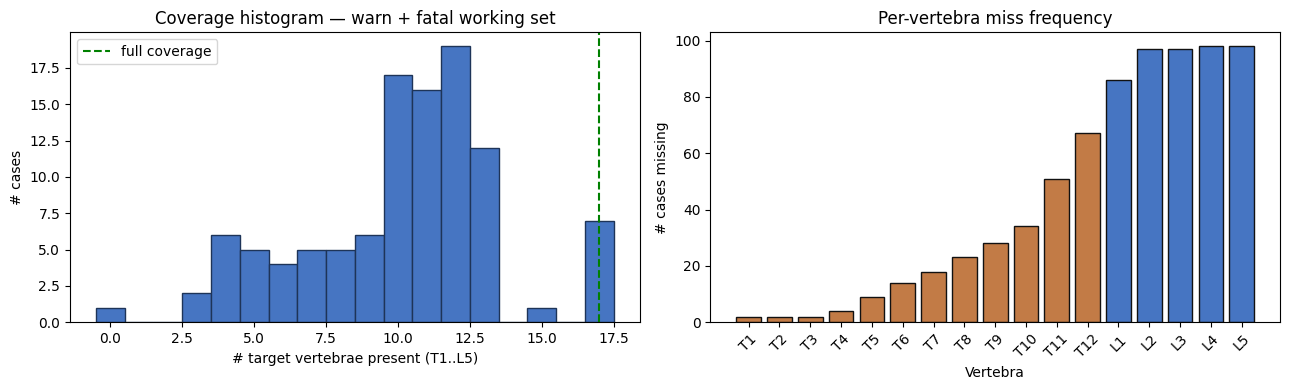

In [4]:
VERTEBRA_ORDER = [
    "T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9", "T10", "T11", "T12",
    "L1", "L2", "L3", "L4", "L5",
]

missing = (
    summary["missing_vertebrae"]
    .fillna("")
    .str.split(";")
    .explode()
)
missing = missing[missing != ""]
miss_counts = (
    missing.value_counts()
    .reindex(VERTEBRA_ORDER, fill_value=0)
)

print(
    "n_target_vertebrae — mean={:.1f}  median={:.0f}  min={}  max={}".format(
        summary["n_target_vertebrae"].mean(),
        summary["n_target_vertebrae"].median(),
        summary["n_target_vertebrae"].min(),
        summary["n_target_vertebrae"].max(),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    summary["n_target_vertebrae"], bins=np.arange(-0.5, 18.5, 1),
    color="#4675c2", edgecolor="#1e3458",
)
axes[0].axvline(17, color="green", ls="--", label="full coverage")
axes[0].set_xlabel("# target vertebrae present (T1..L5)")
axes[0].set_ylabel("# cases")
axes[0].set_title("Coverage histogram — warn + fatal working set")
axes[0].legend()

bar_colors = ["#c27b46" if v.startswith("T") else "#4675c2" for v in miss_counts.index]
axes[1].bar(miss_counts.index, miss_counts.values, color=bar_colors, edgecolor="#111")
axes[1].set_xlabel("Vertebra")
axes[1].set_ylabel("# cases missing")
axes[1].set_title("Per-vertebra miss frequency")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## 4. `id_out_of_range` is noise, not a defect

**Claim.** Every single MaIA case has pixels tagged with IDs outside the T1–L5 target range (IDs 1–5 are cervical C7–C3; IDs 23–35 are auxiliary entities like sacrum and pelvis). This is the entire `info` severity bucket and is correctly filtered out of the working set.

`ai/preprocessing/segmentation.py::remap_to_target_classes` already collapses these to background at training time. The bar chart confirms the distribution — it is uniform coverage, not a sparse anomaly.

info rows                  : 214
  of which id_out_of_range : 214  (=all of them)
  unique cases affected    : 214
  total cases in dataset   : 250


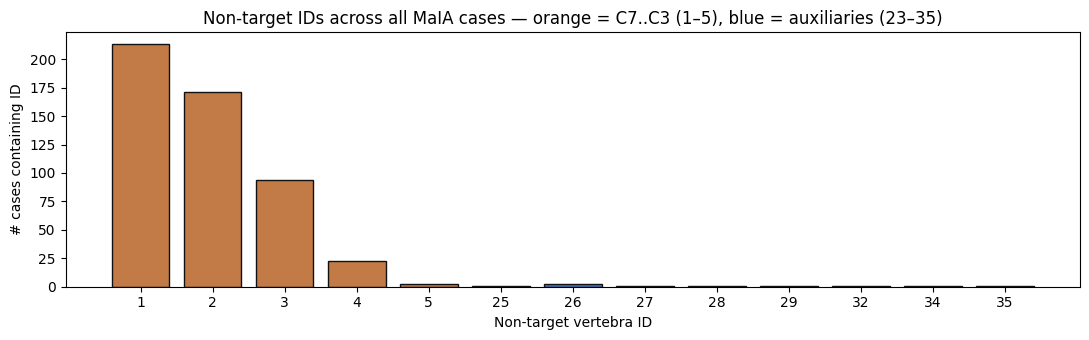

In [5]:
info_rows = known[known["severity"] == "info"]
ior       = info_rows[info_rows["issue_code"] == "id_out_of_range"]
print(f"info rows                  : {len(info_rows)}")
print(f"  of which id_out_of_range : {len(ior)}  (=all of them)")
print(f"  unique cases affected    : {ior[['patient_id', 'category']].drop_duplicates().shape[0]}")
print(f"  total cases in dataset   : {len(clean)}")

# Parse the ID lists out of the free-form `details` column: "non_target_ids=[1, 2, 3]".
import ast
def _extract_ids(details: str) -> list[int]:
    try:
        payload = details.split("=", 1)[1]
        return list(ast.literal_eval(payload))
    except Exception:
        return []

id_hist: dict[int, int] = {}
for d in ior["details"]:
    for i in _extract_ids(d):
        id_hist[i] = id_hist.get(i, 0) + 1
ids   = sorted(id_hist.keys())
freqs = [id_hist[i] for i in ids]
colors = [
    "#c27b46" if 1 <= i <= 5 else ("#4675c2" if 23 <= i <= 35 else "#9aa0a6")
    for i in ids
]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar([str(i) for i in ids], freqs, color=colors, edgecolor="#111")
ax.set_xlabel("Non-target vertebra ID")
ax.set_ylabel("# cases containing ID")
ax.set_title("Non-target IDs across all MaIA cases — orange = C7..C3 (1–5), blue = auxiliaries (23–35)")
fig.tight_layout()
plt.show()

## 5. Hexagonal split paid off for the audit tooling

**Claim.** Splitting the case-summary rendering into a pure function (`ai/visualization/case_summary.py::render_case_summary`) and a script orchestrator (`scripts/build_case_summaries.py`) let us:

- reuse the renderer from notebooks, the CLI, and a future inference adapter without dragging in DVC or FastAPI
- get byte-stable outputs (no timestamps, no unseeded RNG) → DVC can cache the `case_summaries` stage
- enforce the boundary automatically with `tests/test_visualization_architecture.py` — the architectural fitness function bans framework imports inside `ai/visualization/`

The cell below demonstrates point 1: we import the pure function directly, render one case, and embed the resulting PNG inline. The same call is executed by the DVC stage in a subprocess and by future inference code — no copy-paste.

In [6]:
# Showcase: render a single severe case with the pure function, inline.
import sys
sys.path.insert(0, str(REPO_ROOT))

import json as _json
from PIL import Image

from ai.visualization import CaseAudit, render_case_summary

# Pick the single fatal case — S_107, empty mask — as the most informative demo.
demo = summary[summary["severity"] == "fatal"].iloc[0]
cat, pid = demo["category"], int(demo["patient_id"])
print(f"Rendering {cat} case id={pid} severity={demo['severity']} flags={demo['flags']}")

# Pull canonical paths from clean_index.csv — the dataset uses `LabelMulti_{prefix}_{id}.png`
# for masks and occasionally uppercase `.JPG` for images (S_32). clean_index already stores
# the resolved absolute paths, so we just look them up instead of rebuilding.
row = clean[(clean["patient_id"] == pid) & (clean["category"] == cat)].iloc[0]
img_path  = Path(row["image_path"])
mask_path = Path(row["multiclass_mask_path"])
print(f"image: {img_path.relative_to(REPO_ROOT)}")
print(f"mask : {mask_path.relative_to(REPO_ROOT)}")

image = np.asarray(Image.open(img_path).convert("L"), dtype=np.uint8)
mask  = np.asarray(Image.open(mask_path).convert("L"), dtype=np.uint8)

audit = CaseAudit(
    patient_id=pid,
    category=cat,
    severity=demo["severity"],
    issue_codes=tuple(str(demo["flags"]).split(";")),
    cobb_reported_deg=float(demo["cobb_reported_deg"]) if pd.notna(demo["cobb_reported_deg"]) else None,
)

fig, status = render_case_summary(image=image, mask=mask, audit=audit, curve=None)
printable = {k: v for k, v in status.items() if k != "missing_vertebrae"}
print("status:", _json.dumps(printable, default=str))
plt.show()

Rendering Scoliosis case id=107 severity=fatal flags=empty_mask
image: data/raw/MaIA_Scoliosis_Dataset/Scoliosis/S_107.jpg
mask : data/raw/MaIA_Scoliosis_Dataset/LabelMultiClass_ID_PNG/LabelMulti_S_107.png
status: {"render_status": "partial", "render_notes": "no target vertebrae present; no curve data", "n_target_vertebrae": 0, "image_h": 2973, "image_w": 1954, "aspect_ratio": 1.5215, "cobb_reported_deg": null, "cobb_derived_deg": null, "cobb_delta_deg": null, "cobb_endplates_deg": null, "cobb_endplates_delta_deg": null}


/tmp/ipykernel_127004/67918011.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Conclusions

1. **52% of the MaIA dataset is flagged** (133 warn + 1 fatal out of 250). `target_coverage_low` accounts for 74% of warn rows; `resolution_outlier` for 26%; the lone fatal case is `S_107` (empty mask, 0 target vertebrae). Training loops MUST have an explicit policy for these cases \u2014 they cannot be treated as clean data.

2. **Neither Cobb derivation matches MaIA's ground truth.** Centroid polynomial MAE \u2248 10.4\u00b0 (long tail to ~66\u00b0 on balanced double curves); endplate-tilt PCA MAE \u2248 10.9\u00b0 (shorter tail, max ~55\u00b0). Both fall outside the cavekit \u00b12\u00b0 target on the full working set. Root cause: MaIA computes Cobb from *midline curve slopes at inflection points*, while we compute either global slope extrema of a degree-5 polynomial through centroids (method A) or per-vertebra endplate tilt ranges (method B). Both are structurally different geometric quantities. The `build_case_summaries` stage now emits both columns (`cobb_derived_deg`, `cobb_endplates_deg`) so downstream evaluation can compare them; the proper next step is implementing inflection-slope extraction directly from the polynomial fit.

3. **Coverage loss is structural, not random.** Radiographs systematically crop either the upper thoracic (T1\u2013T5) or the lumbar (L4\u2013L5) region. A loss function that ignores missing vertebrae in ground truth is cheaper than throwing away half the dataset and more honest than assuming full coverage.

4. **`id_out_of_range` is noise by design.** All 250 cases contain cervical IDs 1\u20135 and auxiliary IDs 23\u201335 \u2014 the label schema is broader than our target region. `remap_to_target_classes` handles this correctly; the audit correctly demotes it to `info`. No action needed beyond keeping the remap stage in the preprocessing pipeline.

5. **The hexagonal split is worth repeating.** Pure-fn renderer + orchestrator script + architectural fitness test gives us reproducibility, DVC cacheability, and CI-time boundary enforcement for free. The same pattern should apply to the future model-training and inference evaluation tooling.

### Action items
- Wire `case_summaries` into `dvc.yaml` as a proper stage so `dvc repro case_summaries` works end-to-end.
- Implement a *third* Cobb derivation that extracts midline-slope-at-inflection-point from a polynomial fit through the centroids \u2014 this is the only formulation that can actually hit the \u00b12\u00b0 cavekit target against MaIA ground truth.
- Document the exclusion policy for `target_coverage_low` cases in `data/processed/audit/README.md`.
- Lock `S_107` into an explicit `excluded.csv` with reason `empty_mask`.
- Promote this notebook to `notebooks/final/` once action items above are closed.